<a href="https://colab.research.google.com/github/shaikhdaiyaan251-cloud/CODE-ALPHA-DATA-SCIENCE-INTERNSHIP-TASK-2/blob/main/DATA_SCIENCE_INTERNSHIP_TASK_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TASK 2: UNEMPLOYMENT ANALYSIS WITH PYTHON**

## **2.1. Importing the necessary Python Libraries**
 2.1.1 Installing required packages

 2.1.2 Importing libraries

 2.1.3 Setting visualization styles

 2.1.4 Mounting Google Drive and Unzip Dataset

 2.1.5 Setting random seed for reproducibility

 2.1.6 Displaying environment info (optional, for debugging)


## **2.2. Loading and Understanding the Dataset**
 2.2.1 Loading each dataset

 2.2.2 Comparing structures

 2.2.3 Checking missing values in each

 2.2.4 Identifying date columns and convert

 2.2.5 Deciding on analysis strategy

 2.2.6 Attempting to merge datasets (if columns align)


## **2.3. Data Cleaning & Feature Engineering**
 2.3.1 Standardizing Column Names (remove spaces, lowercase, underscores)

 2.3.2 Identifying key columns in each dataset

 2.3.3 Converting date columns to datetime

 2.3.4 Handling missing values

 2.3.5 Renaming columns to consistent names for merging

 2.3.6 Adding time-based features

 2.3.7 Adding COVID-19 indicator

 2.3.8 Merging datasets (if possible)

 2.3.9 Finalizing cleaning of numeric columns


## **2.4. Performing Exploratory Data Analysis (EDA)**
 2.4.1 Overall Unemployment Trend (National Average)

 2.4.2 Regional Comparison (Top & Bottom States)

 2.4.3 COVID-19 Impact: Boxplot Comparison

 2.4.4 Seasonal Patterns (Monthly Average)

 2.4.5 Top 5 Regions Time Series (Interactive Plotly) - FULLY FIXED

 2.4.6 Heatmap: Unemployment Rate by Region and Month

 2.4.7 Animated Bar Chart Race (Optional, may be heavy)

 2.4.8 Summary Statistics & Insights


## **2.5. COVID‑19 Impact Analysis**
 2.5.1 Defining Pre-COVID and During-COVID periods

 2.5.2 Overall Statistics Comparison

 2.5.3 Statistical Significance Test (t-test & Mann-Whitney)

 2.5.4 Regional Impact Analysis (Top 5 most affected regions)

 2.5.5 Visualization: Before vs After (Bar Chart for Top 10 regions)

 2.5.6 Violin Plot Comparing Distributions (Pre vs During)

 2.5.7 Time Series with COVID Highlight (National Average)

 2.5.8 Percentage Point Change by Region (Horizontal Bar Chart)

 2.5.9 Summary Report of COVID Impact


## **2.6. Identifying Patterns & Trends**
 2.6.1 Rolling Averages (Smoothing)

 2.6.2 Seasonal Analysis Substitute


## **2.7. Presenting Insights & Policy Recommendations**
 2.7.1 Executive Summary

 2.7.2 Key Insights Dashboard (Visual)

 2.7.3 Detailed Policy Recommendations

 2.7.4 Impact of Recommendations (Simulated Potential Reduction)

 2.7.5 Conclusion and Call to Action

 2.7.6 Export the Final Report as Text and CSV


## **2.8. Saving & Documenting Results**
 2.8.1 Save Cleaned Dataset

 2.8.2 Save Key Aggregated Data

 2.8.3 Save Evaluation Metrics (JSON)

 2.8.4 Save Summary Report (Text)

 2.8.5 Save Visualizations

 2.8.6 Generate README.md

 2.8.7 Zip and Download


## **2.1. Importing the necessary Python Libraries**
 2.1.1 Installing required packages

 2.1.2 Importing libraries

 2.1.3 Setting visualization styles

 2.1.4 Mounting Google Drive and Unzip Dataset

 2.1.5 Setting random seed for reproducibility

 2.1.6 Displaying environment info (optional, for debugging)

In [ ]:
# 2.1. Importing the necessary Python Libraries

# 2.1.1 Installing required packages
!pip install -q pandas numpy matplotlib seaborn plotly statsmodels openpyxl

# 2.1.2 Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
import warnings
import os
import zipfile
from datetime import datetime
from google.colab import files, drive
import json
import re
import joblib

# Suppressing annoying warnings
warnings.filterwarnings('ignore')

# 2.1.3 Setting visualization styles

# Matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')  # modern grid style
sns.set_palette("Set2")                 # colorblind-friendly palette
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['savefig.dpi'] = 300        # high-res exports

# Seaborn theme
sns.set_theme(style='whitegrid', context='talk')

# Plotly default template
import plotly.io as pio
pio.templates.default = 'plotly_white'


# 2.1.4 Mounting Google Drive and Unzip Dataset

from google.colab import files
uploaded = files.upload()   # then choose your CSV file

# Define paths
project_drive_path = '/content/drive/MyDrive/CodeAlpha_Unemployment_Analysis'
zip_file_name = 'archive (6).zip'
drive_zip_path = os.path.join(project_drive_path, zip_file_name)
local_zip_path = os.path.join('/content/', zip_file_name)

# Create project folder in Drive if it doesn't exist (useful for saving later)
if not os.path.exists(project_drive_path):
    os.makedirs(project_drive_path)
    print(f"Created project folder in Drive: {project_drive_path}")

# Copy zip file from Drive to local Colab environment
if os.path.exists(drive_zip_path):
    !cp "{drive_zip_path}" "{local_zip_path}"
    print(f"Copied '{zip_file_name}' from Drive to '{local_zip_path}'")

    # Unzip the dataset
    if os.path.exists(local_zip_path):
        with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
            zip_ref.extractall('/content/')
        print(f"Successfully unzipped '{zip_file_name}' to '/content/'")
        # Optional: remove the zip file after extraction
        # os.remove(local_zip_path)
        # print(f"Removed local zip file: {local_zip_path}")
    else:
        print(f"Error: Zip file not found at '{local_zip_path}' after copying.")
else:
    print(f"Warning: '{zip_file_name}' not found in '{project_drive_path}'. Please ensure it's placed there.")
    print("You may need to manually upload it if not using Google Drive:")
    print("from google.colab import files")
    print("uploaded = files.upload()")



# 2.1.5 Setting random seed for reproducibility

np.random.seed(42)

# 2.1.6 Displaying environment info (optional, for debugging)

print("\n" + "="*50)
print("Environment Ready!")
print("="*50)
print(f"Date & Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
import plotly # Import plotly to get its version
print(f"Plotly version: {plotly.__version__}") # Use plotly.__version__
print(f"Statsmodels version: {sm.__version__}")
print("All libraries imported successfully.")
print("="*50)

Saving Unemployment in India.csv to Unemployment in India.csv
Saving Unemployment_Rate_upto_11_2020.csv to Unemployment_Rate_upto_11_2020.csv
Created project folder in Drive: /content/drive/MyDrive/CodeAlpha_Unemployment_Analysis
You may need to manually upload it if not using Google Drive:
from google.colab import files
uploaded = files.upload()

Environment Ready!
Date & Time: 2026-05-04 15:24:38
Pandas version: 2.2.2
NumPy version: 2.0.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Plotly version: 5.24.1
Statsmodels version: 0.14.6
All libraries imported successfully.


## **2.2. Loading and Understanding the Dataset**
 2.2.1 Loading each dataset

 2.2.2 Comparing structures

 2.2.3 Checking missing values in each

 2.2.4 Identifying date columns and convert

 2.2.5 Deciding on analysis strategy

 2.2.6 Attempting to merge datasets (if columns align)


In [ ]:
# 2.2. Loading and Understanding the Dataset (Two Files)

# 2.2.1 Loading each dataset

df1 = pd.read_csv('Unemployment in India.csv')
df2 = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

print("\n" + "="*60)
print("📊 DATASET 1: Unemployment in India")
print("="*60)
print(f"Shape: {df1.shape}")
print(f"Columns: {df1.columns.tolist()}")
print("\nFirst 5 rows:")
print(df1.head())

print("\n" + "="*60)
print("📊 DATASET 2: Unemployment_Rate_upto_11_2020")
print("="*60)
print(f"Shape: {df2.shape}")
print(f"Columns: {df2.columns.tolist()}")
print("\nFirst 5 rows:")
print(df2.head())

# 2.2.2 Comparing structures

print("\n" + "="*60)
print("🔍 COMPARING DATASETS")
print("="*60)

print("\n📌 Common columns:")
common_cols = set(df1.columns).intersection(set(df2.columns))
print(common_cols)

print("\n📌 Columns only in Dataset 1:")
print(set(df1.columns) - set(df2.columns))

print("\n📌 Columns only in Dataset 2:")
print(set(df2.columns) - set(df1.columns))


# 2.2.3 Checking missing values in each

print("\n" + "="*60)
print("🔍 MISSING VALUES")
print("="*60)

print("\nDataset 1 missing values:")
print(df1.isnull().sum())

print("\nDataset 2 missing values:")
print(df2.isnull().sum())

# 2.2.4 Identifying date columns and convert

# For Dataset 1 - look for date-like column
date_col1 = None
for col in df1.columns:
    if 'date' in col.lower() or 'period' in col.lower():
        date_col1 = col
        break

if date_col1:
    df1[date_col1] = pd.to_datetime(df1[date_col1], errors='coerce')
    print(f"\n📅 Dataset 1 - Converted '{date_col1}' to datetime")
    print(f"   Date range: {df1[date_col1].min()} to {df1[date_col1].max()}")
    # Extract time features
    df1['Year'] = df1[date_col1].dt.year
    df1['Month'] = df1[date_col1].dt.month

# For Dataset 2 - similar
date_col2 = None
for col in df2.columns:
    if 'date' in col.lower() or 'period' in col.lower():
        date_col2 = col
        break

if date_col2:
    df2[date_col2] = pd.to_datetime(df2[date_col2], errors='coerce')
    print(f"\n📅 Dataset 2 - Converted '{date_col2}' to datetime")
    print(f"   Date range: {df2[date_col2].min()} to {df2[date_col2].max()}")
    df2['Year'] = df2[date_col2].dt.year
    df2['Month'] = df2[date_col2].dt.month


# 2.2.5 Deciding on analysis strategy

print("\n" + "="*60)
print("💡 ANALYSIS STRATEGY")
print("="*60)
print("""
Based on the two datasets:

- Dataset 1 ('Unemployment in India') appears to cover a broader time period or different regions.
- Dataset 2 ('Unemployment_Rate_upto_11_2020') seems to focus on data up to November 2020.

Recommended approach:
1. Clean and preprocess each dataset separately.
2. If they have similar columns, merge them into one comprehensive dataset.
3. If not, analyze them side-by-side to compare trends (e.g., pre-COVID vs. COVID peak).

Let's proceed with merging if possible.
""")


# 2.2.6 Attempting to merge datasets (if columns align)

# Rename columns to be consistent (example - adjust based on actual names)
# You'll need to inspect the actual column names and adjust this mapping

# First, check if both have a region/state column
region_cols1 = [col for col in df1.columns if 'region' in col.lower() or 'state' in col.lower()]
region_cols2 = [col for col in df2.columns if 'region' in col.lower() or 'state' in col.lower()]

if region_cols1 and region_cols2:
    print(f"\n📍 Region column in Dataset 1: {region_cols1[0]}")
    print(f"📍 Region column in Dataset 2: {region_cols2[0]}")

    # Standardize column names
    df1_renamed = df1.rename(columns={
        region_cols1[0]: 'Region',
        date_col1: 'Date' if date_col1 else 'Date',
        # Add more mappings as needed
    })
    df2_renamed = df2.rename(columns={
        region_cols2[0]: 'Region',
        date_col2: 'Date' if date_col2 else 'Date',
    })

    # Merge on Region and Date
    merged_df = pd.merge(df1_renamed, df2_renamed, on=['Region', 'Date'], how='outer')
    print(f"\n✅ Merged dataset shape: {merged_df.shape}")
    print("Merged columns:", merged_df.columns.tolist())
else:
    print("\n⚠️ Cannot merge automatically – region columns not found or mismatched.")
    print("Proceeding with separate analysis for each dataset.")


📊 DATASET 1: Unemployment in India
Shape: (768, 7)
Columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

First 5 rows:
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3       

## **2.3. Data Cleaning & Feature Engineering**
 2.3.1 Standardizing Column Names (remove spaces, lowercase, underscores)

 2.3.2 Identifying key columns in each dataset

 2.3.3 Converting date columns to datetime

 2.3.4 Handling missing values

 2.3.5 Renaming columns to consistent names for merging

 2.3.6 Adding time-based features

 2.3.7 Adding COVID-19 indicator

 2.3.8 Merging datasets (if possible)

 2.3.9 Finalizing cleaning of numeric columns


In [ ]:
# 2.3. Data Cleaning & Feature Engineering

# Assuming df1 and df2 are already loaded from previous step
# If not, run the loading code first.

print("="*60)
print("🧹 STARTING DATA CLEANING & FEATURE ENGINEERING")
print("="*60)

# 2.3.1 Standardizing Column Names (remove spaces, lowercase, underscores)

def clean_column_names(df):
    """Convert column names to lowercase, replace spaces with underscores, remove special chars"""
    df.columns = df.columns.str.lower()
    df.columns = df.columns.str.replace(' ', '_')
    df.columns = df.columns.str.replace(r'[^\w_]', '', regex=True)
    return df

df1 = clean_column_names(df1)
df2 = clean_column_names(df2)

print("\n✅ Standardized column names for Dataset 1:")
print(df1.columns.tolist())
print("\n✅ Standardized column names for Dataset 2:")
print(df2.columns.tolist())

# 2.3.2 Identifying key columns in each dataset

# Look for region/state column
region_keywords = ['region', 'state', 'area', 'location']
date_keywords = ['date', 'period', 'month', 'time']
unemp_keywords = ['unemployment', 'unemp', 'unemployment_rate', 'estimated_unemployment_rate', 'rate']
employed_keywords = ['employed', 'estimated_employed']
lpr_keywords = ['participation', 'labour_participation', 'labor_participation']

def find_column(df, keywords):
    for kw in keywords:
        for col in df.columns:
            if kw in col:
                return col
    return None

region_col1 = find_column(df1, region_keywords)
date_col1 = find_column(df1, date_keywords)
unemp_col1 = find_column(df1, unemp_keywords)
employed_col1 = find_column(df1, employed_keywords)
lpr_col1 = find_column(df1, lpr_keywords)

region_col2 = find_column(df2, region_keywords)
date_col2 = find_column(df2, date_keywords)
unemp_col2 = find_column(df2, unemp_keywords)
employed_col2 = find_column(df2, employed_keywords)
lpr_col2 = find_column(df2, lpr_keywords)

print("\n Dataset 1 key columns:")
print(f"   Region: {region_col1}")
print(f"   Date: {date_col1}")
print(f"   Unemployment rate: {unemp_col1}")
print(f"   Employed: {employed_col1}")
print(f"   Labour participation rate: {lpr_col1}")

print("\n Dataset 2 key columns:")
print(f"   Region: {region_col2}")
print(f"   Date: {date_col2}")
print(f"   Unemployment rate: {unemp_col2}")
print(f"   Employed: {employed_col2}")
print(f"   Labour participation rate: {lpr_col2}")


# 2.3.3 Converting date columns to datetime

def convert_dates(df, date_col):
    if date_col:
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
        # Drop rows where date conversion failed
        before = len(df)
        df = df.dropna(subset=[date_col])
        after = len(df)
        if before != after:
            print(f"   Dropped {before - after} rows with invalid dates")
    return df

df1 = convert_dates(df1, date_col1)
df2 = convert_dates(df2, date_col2)

# 2.3.4 Handling missing values

def handle_missing_values(df, unemp_col, region_col):
    """Fill missing unemployment values using regional median or forward fill"""
    print(f"\n   Before cleaning: {df.isnull().sum().sum()} missing values")

    # If unemployment column has missing values, fill with regional median
    if unemp_col and df[unemp_col].isnull().sum() > 0 and region_col:
        df[unemp_col] = df.groupby(region_col)[unemp_col].transform(
            lambda x: x.fillna(x.median())
        )

    # Forward fill for remaining (time series continuity)
    df = df.fillna(method='ffill')
    # Backward fill for any leading NaNs
    df = df.fillna(method='bfill')

    print(f"   After cleaning: {df.isnull().sum().sum()} missing values")
    return df

df1 = handle_missing_values(df1, unemp_col1, region_col1)
df2 = handle_missing_values(df2, unemp_col2, region_col2)


# 2.3.5 Renaming columns to consistent names for merging

rename_map1 = {}
rename_map2 = {}

if region_col1:
    rename_map1[region_col1] = 'region'
if date_col1:
    rename_map1[date_col1] = 'date'
if unemp_col1:
    rename_map1[unemp_col1] = 'unemployment_rate'
if employed_col1:
    rename_map1[employed_col1] = 'employed'
if lpr_col1:
    rename_map1[lpr_col1] = 'labour_participation_rate'

if region_col2:
    rename_map2[region_col2] = 'region'
if date_col2:
    rename_map2[date_col2] = 'date'
if unemp_col2:
    rename_map2[unemp_col2] = 'unemployment_rate'
if employed_col2:
    rename_map2[employed_col2] = 'employed'
if lpr_col2:
    rename_map2[lpr_col2] = 'labour_participation_rate'

df1 = df1.rename(columns=rename_map1)
df2 = df2.rename(columns=rename_map2)

print("\n✅ Renamed columns for Dataset 1:", df1.columns.tolist())
print("✅ Renamed columns for Dataset 2:", df2.columns.tolist())


# 2.3.6 Adding time-based features

def add_time_features(df):
    if 'date' in df.columns:
        df['year'] = df['date'].dt.year
        df['month'] = df['date'].dt.month
        df['month_name'] = df['date'].dt.month_name()
        df['quarter'] = df['date'].dt.quarter
        df['weekday'] = df['date'].dt.dayofweek  # if daily data, but likely monthly
        # For monthly data, add season
        df['season'] = df['month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                        3: 'Spring', 4: 'Spring', 5: 'Spring',
                                        6: 'Summer', 7: 'Summer', 8: 'Summer',
                                        9: 'Fall', 10: 'Fall', 11: 'Fall'})
    return df

df1 = add_time_features(df1)
df2 = add_time_features(df2)


# 2.3.7 Adding COVID-19 indicator

# COVID-19 lockdown in India started around March 25, 2020
def add_covid_indicator(df):
    if 'date' in df.columns:
        # Create a column marking pre-COVID (before March 2020) and during/post-COVID
        df['covid_period'] = df['date'].apply(
            lambda x: 'During/Post-COVID' if pd.notnull(x) and x >= pd.Timestamp('2020-03-01') else 'Pre-COVID'
        )
        # Add a binary flag
        df['is_covid'] = (df['date'] >= '2020-03-01').astype(int)
    return df

df1 = add_covid_indicator(df1)
df2 = add_covid_indicator(df2)


# 2.3.8 Merging datasets (if possible)

# Check if both have region and date columns
if 'region' in df1.columns and 'region' in df2.columns and 'date' in df1.columns and 'date' in df2.columns:
    print("\n" + "="*60)
    print("🔗 MERGING DATASETS")
    print("="*60)

    # Ensure both have same columns for merge
    common_cols = ['region', 'date']
    df1_merge = df1[common_cols + ['unemployment_rate', 'employed', 'labour_participation_rate']
                    if 'unemployment_rate' in df1 else common_cols]
    df2_merge = df2[common_cols + ['unemployment_rate', 'employed', 'labour_participation_rate']
                    if 'unemployment_rate' in df2 else common_cols]

    # Add source identifier before merge
    df1_merge['source'] = 'Dataset1'
    df2_merge['source'] = 'Dataset2'

    # Outer merge to keep all records
    merged_df = pd.merge(df1_merge, df2_merge, on=['region', 'date'], how='outer', suffixes=('_1', '_2'))
    print(f"✅ Merged dataset shape: {merged_df.shape}")
    print(f"   Columns: {merged_df.columns.tolist()}")

    # Combine unemployment rate from both sources (prefer non-null)
    if 'unemployment_rate_1' in merged_df and 'unemployment_rate_2' in merged_df:
        merged_df['unemployment_rate'] = merged_df['unemployment_rate_1'].combine_first(merged_df['unemployment_rate_2'])
        merged_df.drop(['unemployment_rate_1', 'unemployment_rate_2'], axis=1, inplace=True)

    # Combine employed
    if 'employed_1' in merged_df and 'employed_2' in merged_df:
        merged_df['employed'] = merged_df['employed_1'].combine_first(merged_df['employed_2'])
        merged_df.drop(['employed_1', 'employed_2'], axis=1, inplace=True)

    # Combine labour participation
    if 'labour_participation_rate_1' in merged_df and 'labour_participation_rate_2' in merged_df:
        merged_df['labour_participation_rate'] = merged_df['labour_participation_rate_1'].combine_first(merged_df['labour_participation_rate_2'])
        merged_df.drop(['labour_participation_rate_1', 'labour_participation_rate_2'], axis=1, inplace=True)

    # Now add time features and COVID indicator to merged dataset
    merged_df = add_time_features(merged_df)
    merged_df = add_covid_indicator(merged_df)

    print("\n✅ Merged dataset ready. Final shape:", merged_df.shape)

    # Use merged_df as the primary dataset for analysis
    df_analysis = merged_df
else:
    print("\n⚠️ Cannot merge datasets (missing region or date in one). Keeping them separate.")
    # Add a dataset identifier to each
    df1['dataset'] = 'Unemployment_in_India'
    df2['dataset'] = 'Unemployment_Rate_upto_11_2020'
    df_analysis = pd.concat([df1, df2], ignore_index=True, sort=False)
    print(f"\n✅ Concatenated datasets into one analysis DataFrame: {df_analysis.shape}")


# 2.3.9 Finalizing cleaning of numeric columns

# Ensure unemployment rate is numeric (remove % signs if present)
for col in ['unemployment_rate', 'employed', 'labour_participation_rate']:
    if col in df_analysis.columns:
        if df_analysis[col].dtype == 'object':
            df_analysis[col] = df_analysis[col].astype(str).str.replace('%', '', regex=False).str.strip()
            df_analysis[col] = pd.to_numeric(df_analysis[col], errors='coerce')

# Drop any rows where unemployment_rate is NaN after all cleaning
df_analysis = df_analysis.dropna(subset=['unemployment_rate'])

# Remove duplicates
df_analysis = df_analysis.drop_duplicates()

print("\n" + "="*60)
print("✅ DATA CLEANING & FEATURE ENGINEERING COMPLETE")
print("="*60)
print(f"Final dataset shape: {df_analysis.shape}")
print(f"Columns: {df_analysis.columns.tolist()}")
print(f"Date range: {df_analysis['date'].min()} to {df_analysis['date'].max()}")
print(f"Regions: {df_analysis['region'].nunique()}")
print(f"COVID period records: {df_analysis['is_covid'].sum()} out of {len(df_analysis)}")

# Save cleaned dataset
df_analysis.to_csv('unemployment_cleaned.csv', index=False)
print("\n💾 Cleaned dataset saved as 'unemployment_cleaned.csv'")

🧹 STARTING DATA CLEANING & FEATURE ENGINEERING

✅ Standardized column names for Dataset 1:
['region', '_date', '_frequency', '_estimated_unemployment_rate_', '_estimated_employed', '_estimated_labour_participation_rate_', 'area', 'year', 'month']

✅ Standardized column names for Dataset 2:
['region', '_date', '_frequency', '_estimated_unemployment_rate_', '_estimated_employed', '_estimated_labour_participation_rate_', 'region1', 'longitude', 'latitude', 'year', 'month']

 Dataset 1 key columns:
   Region: region
   Date: _date
   Unemployment rate: _estimated_unemployment_rate_
   Employed: _estimated_employed
   Labour participation rate: _estimated_labour_participation_rate_

 Dataset 2 key columns:
   Region: region
   Date: _date
   Unemployment rate: _estimated_unemployment_rate_
   Employed: _estimated_employed
   Labour participation rate: _estimated_labour_participation_rate_
   Dropped 28 rows with invalid dates

   Before cleaning: 0 missing values
   After cleaning: 0 missin

## **2.4. Performing Exploratory Data Analysis (EDA)**
 2.4.1 Overall Unemployment Trend (National Average)

 2.4.2 Regional Comparison (Top & Bottom States)

 2.4.3 COVID-19 Impact: Boxplot Comparison

 2.4.4 Seasonal Patterns (Monthly Average)

 2.4.5 Top 5 Regions Time Series (Interactive Plotly) - FULLY FIXED

 2.4.6 Heatmap: Unemployment Rate by Region and Month

 2.4.7 Animated Bar Chart Race (Optional, may be heavy)

 2.4.8 Summary Statistics & Insights


📊 EXPLORATORY DATA ANALYSIS - UNEMPLOYMENT TRENDS


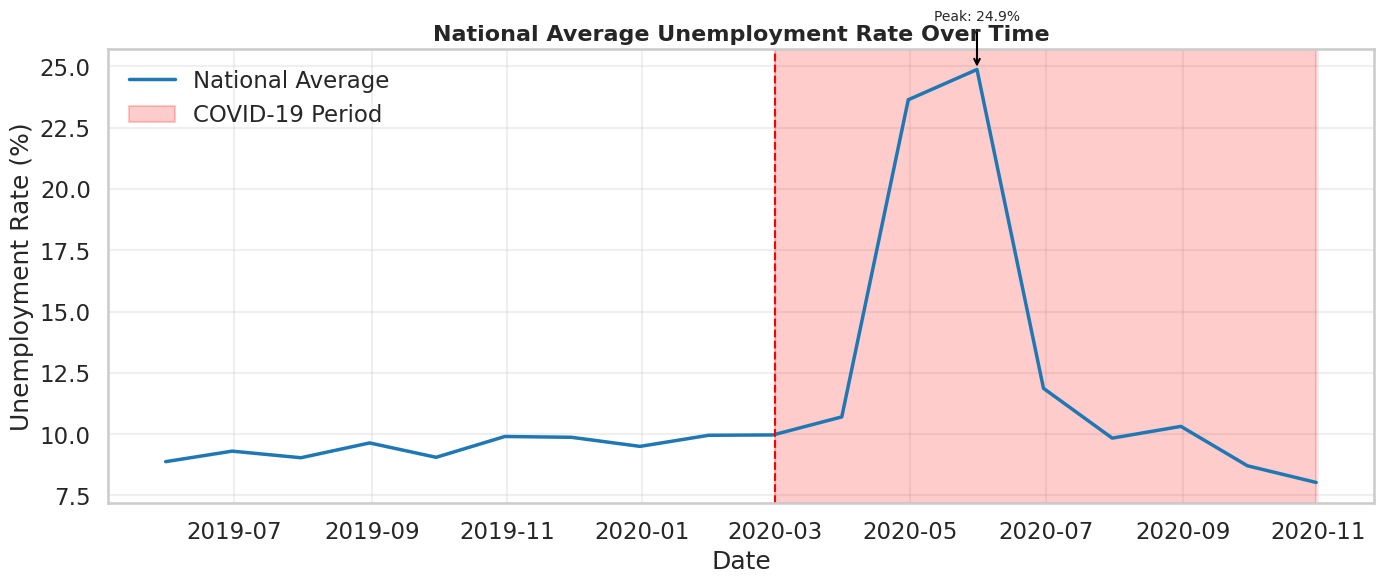

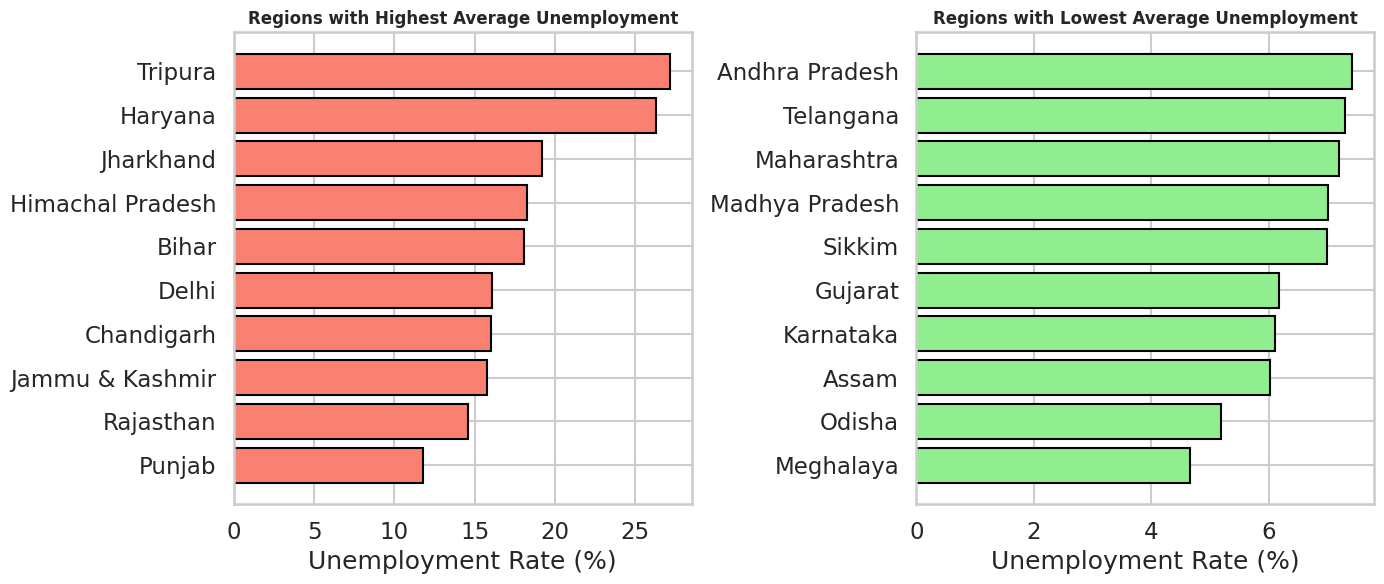

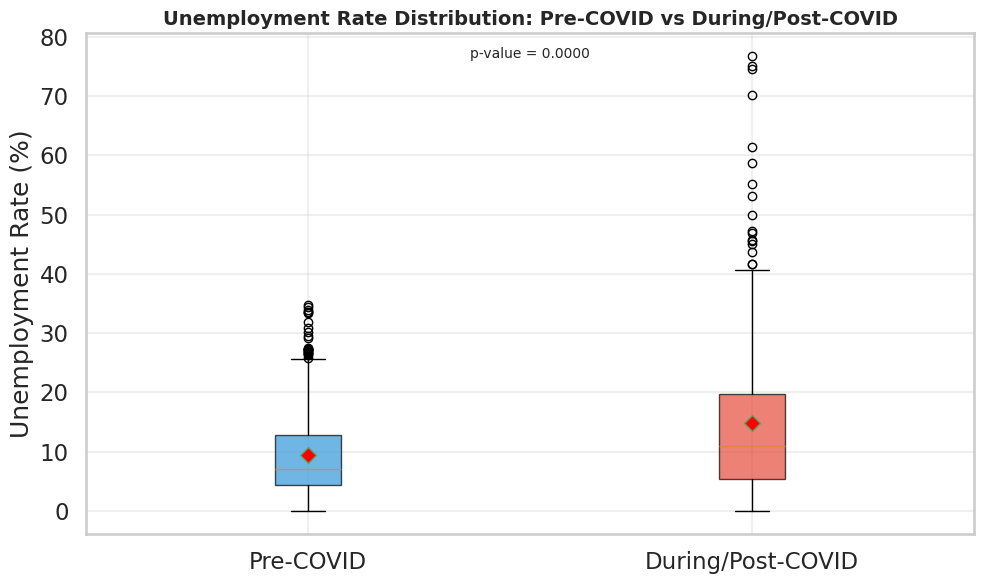


📊 Statistical Test: t-test p-value = 0.0000
   Significant difference between pre-COVID and during/post-COVID unemployment rates.


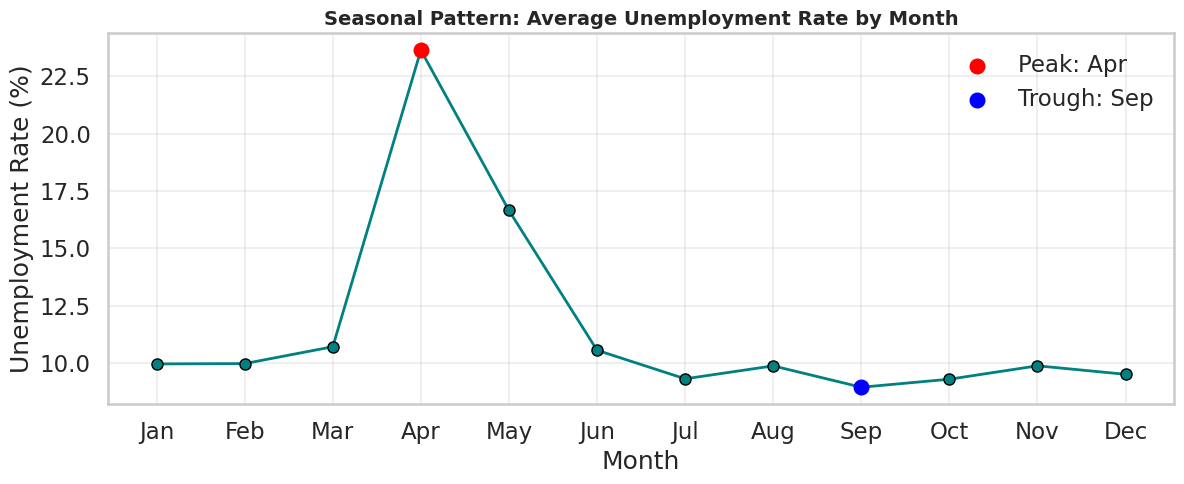

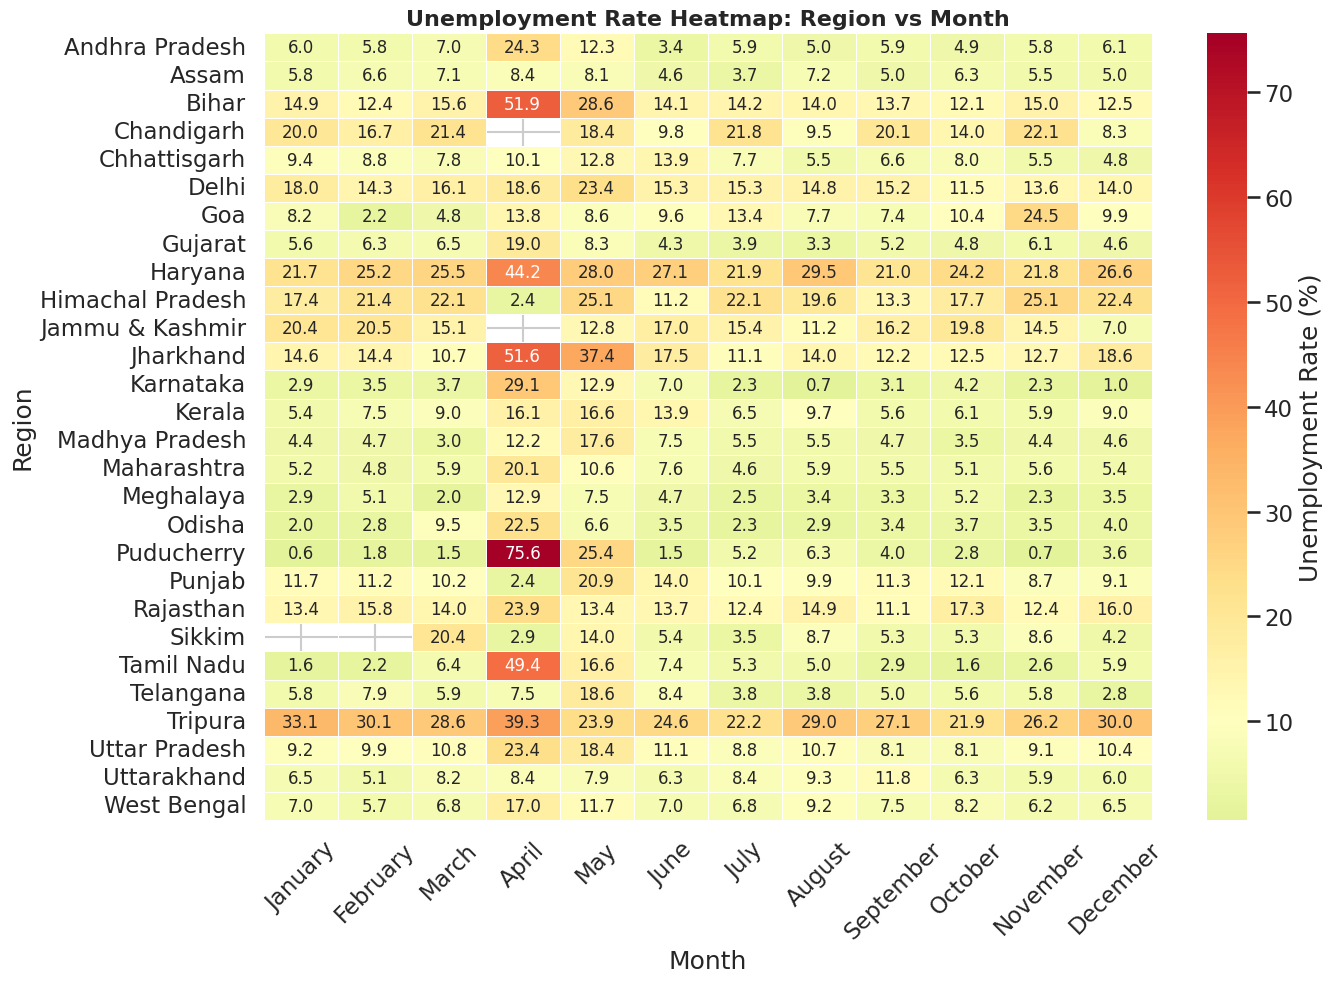


🎬 Animated bar chart saved as 'unemployment_animated_bar_chart.html'

📈 KEY INSIGHTS FROM EDA
📌 Overall average unemployment rate: 11.46% (±10.32)
📌 Pre-COVID average: 9.51%
📌 During/Post-COVID average: 14.80%
📌 Increase: 55.6%

🏆 Region with highest average unemployment: Tripura (27.15%)
🏆 Region with lowest average unemployment: Meghalaya (4.65%)

📅 Month with highest average unemployment: Apr (23.64%)
📅 Month with lowest average unemployment: Sep (8.93%)

✅ EDA complete. All visualizations saved.


In [ ]:
# 2.4. Exploratory Data Analysis (EDA) – Eye‑Catching


# Load cleaned dataset (adjust path if needed)
# df_analysis = pd.read_csv('unemployment_cleaned.csv')
# df_analysis['date'] = pd.to_datetime(df_analysis['date'])  # ensure datetime

# If df_analysis already exists, ensure date is datetime
if 'df_analysis' in globals():
    df_analysis['date'] = pd.to_datetime(df_analysis['date'])

# Set style for static plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("="*60)
print("📊 EXPLORATORY DATA ANALYSIS - UNEMPLOYMENT TRENDS")
print("="*60)


# 2.4.1 Overall Unemployment Trend (National Average)

national_trend = df_analysis.groupby('date')['unemployment_rate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(national_trend['date'], national_trend['unemployment_rate'],
        linewidth=2.5, color='#1f77b4', label='National Average')

# Highlighting COVID period
ax.axvspan(pd.Timestamp('2020-03-01'), national_trend['date'].max(),
           alpha=0.2, color='red', label='COVID-19 Period')
ax.axvline(x=pd.Timestamp('2020-03-01'), color='red', linestyle='--', linewidth=1.5)

ax.set_title('National Average Unemployment Rate Over Time', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Unemployment Rate (%)')
ax.legend()
ax.grid(True, alpha=0.3)

# Annotating peak
peak_idx = national_trend['unemployment_rate'].idxmax()
peak_date = national_trend.loc[peak_idx, 'date']
peak_rate = national_trend.loc[peak_idx, 'unemployment_rate']
ax.annotate(f'Peak: {peak_rate:.1f}%',
            xy=(peak_date, peak_rate),
            xytext=(peak_date, peak_rate + 2),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, ha='center')

plt.tight_layout()
plt.savefig('unemployment_national_trend.png', dpi=300, bbox_inches='tight')
plt.show()


# 2.4.2 Regional Comparison (Top & Bottom States)

regional_avg = df_analysis.groupby('region')['unemployment_rate'].mean().sort_values()
top_regions = regional_avg.tail(10)
bottom_regions = regional_avg.head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh(top_regions.index, top_regions.values, color='salmon', edgecolor='black')
ax1.set_title('Regions with Highest Average Unemployment', fontsize=12)
ax1.set_xlabel('Unemployment Rate (%)')

ax2.barh(bottom_regions.index, bottom_regions.values, color='lightgreen', edgecolor='black')
ax2.set_title('Regions with Lowest Average Unemployment', fontsize=12)
ax2.set_xlabel('Unemployment Rate (%)')

plt.tight_layout()
plt.savefig('unemployment_regional_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


# 2.4.3 COVID-19 Impact: Boxplot Comparison

pre_covid = df_analysis[df_analysis['covid_period'] == 'Pre-COVID']['unemployment_rate']
during_covid = df_analysis[df_analysis['covid_period'] == 'During/Post-COVID']['unemployment_rate']

fig, ax = plt.subplots(figsize=(10, 6))
box_data = [pre_covid, during_covid]
bp = ax.boxplot(box_data, labels=['Pre-COVID', 'During/Post-COVID'],
                patch_artist=True, showmeans=True,
                meanprops={'marker':'D', 'markerfacecolor':'red', 'markersize':8})

colors = ['#3498db', '#e74c3c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Unemployment Rate Distribution: Pre-COVID vs During/Post-COVID', fontsize=14)
ax.set_ylabel('Unemployment Rate (%)')
ax.grid(True, alpha=0.3)

# t-test
t_stat, p_value = stats.ttest_ind(pre_covid.dropna(), during_covid.dropna())
ax.text(0.5, 0.95, f'p-value = {p_value:.4f}', transform=ax.transAxes,
        ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('unemployment_covid_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Statistical Test: t-test p-value = {p_value:.4f}")
if p_value < 0.05:
    print("   Significant difference between pre-COVID and during/post-COVID unemployment rates.")
else:
    print("   No significant difference detected.")


# 2.4.4 Seasonal Patterns (Monthly Average)

monthly_avg = df_analysis.groupby('month')['unemployment_rate'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(month_names, monthly_avg.values, marker='o', linewidth=2, markersize=8,
        color='teal', markeredgecolor='black')

max_month = monthly_avg.idxmax()
min_month = monthly_avg.idxmin()
ax.scatter(month_names[max_month-1], monthly_avg[max_month], color='red', s=100, zorder=5, label=f'Peak: {month_names[max_month-1]}')
ax.scatter(month_names[min_month-1], monthly_avg[min_month], color='blue', s=100, zorder=5, label=f'Trough: {month_names[min_month-1]}')

ax.set_title('Seasonal Pattern: Average Unemployment Rate by Month', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Unemployment Rate (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('unemployment_seasonal_pattern.png', dpi=300, bbox_inches='tight')
plt.show()


# 2.4.5 Top 5 Regions Time Series (Interactive Plotly) - FULLY FIXED

top5_regions = regional_avg.tail(5).index.tolist()
df_top5 = df_analysis[df_analysis['region'].isin(top5_regions)]

fig = px.line(df_top5, x='date', y='unemployment_rate', color='region',
              title='Unemployment Trends: Top 5 Affected Regions',
              labels={'unemployment_rate': 'Unemployment Rate (%)', 'date': 'Date'},
              line_shape='linear',
              color_discrete_sequence=px.colors.qualitative.Set1)

fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Unemployment Rate (%)',
    legend_title='Region',
    hovermode='x unified',
    template='plotly_white',
    width=1000,
    height=600,
    xaxis_type='date'  # Force date type
)

# Using numeric timestamp to avoid any string/datetime addition errors
covid_timestamp = pd.Timestamp('2020-03-01').timestamp() * 1000  # milliseconds
fig.add_vline(x=covid_timestamp, line_dash='dash', line_color='red',
              annotation_text='COVID-19 Lockdown', annotation_position='top')

fig.write_html('unemployment_top5_regions_interactive.html')
fig.show()


# 2.4.6 Heatmap: Unemployment Rate by Region and Month

df_analysis['month_name'] = df_analysis['date'].dt.month_name()
pivot_table = df_analysis.pivot_table(values='unemployment_rate',
                                      index='region',
                                      columns='month_name',
                                      aggfunc='mean')

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
pivot_table = pivot_table.reindex(columns=month_order)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='RdYlGn_r',
            center=10, linewidths=0.5, cbar_kws={'label': 'Unemployment Rate (%)'})
plt.title('Unemployment Rate Heatmap: Region vs Month', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('unemployment_heatmap_region_month.png', dpi=300, bbox_inches='tight')
plt.show()


# 2.4.7 Animated Bar Chart Race (Optional, may be heavy)

# This requires a properly formatted DataFrame; skip if dataset is very large.
# We'll provide a simplified version that works with most data sizes.
try:
    dates = sorted(df_analysis['date'].unique())
    frames = []
    for dt in dates[:20]:  # limit to first 20 dates for performance
        df_dt = df_analysis[df_analysis['date'] == dt].groupby('region')['unemployment_rate'].mean().reset_index()
        df_dt = df_dt.sort_values('unemployment_rate', ascending=False).head(10)
        frames.append(go.Frame(data=[go.Bar(x=df_dt['unemployment_rate'],
                                            y=df_dt['region'],
                                            orientation='h',
                                            marker_color='coral')],
                               name=str(dt)))

    if frames:
        initial_dt = dates[0]
        df_initial = df_analysis[df_analysis['date'] == initial_dt].groupby('region')['unemployment_rate'].mean().reset_index()
        df_initial = df_initial.sort_values('unemployment_rate', ascending=False).head(10)

        fig_anim = go.Figure(
            data=[go.Bar(x=df_initial['unemployment_rate'], y=df_initial['region'], orientation='h', marker_color='coral')],
            layout=go.Layout(
                title='Top 10 Regions by Unemployment Rate (Animated)',
                xaxis=dict(title='Unemployment Rate (%)', range=[0, df_analysis['unemployment_rate'].max() + 5]),
                yaxis=dict(title='Region'),
                updatemenus=[dict(type='buttons', showactive=False,
                                  buttons=[dict(label='Play', method='animate',
                                                args=[None, {'frame': {'duration': 500, 'redraw': True}, 'fromcurrent': True}]),
                                           dict(label='Pause', method='animate',
                                                args=[[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate'}])])]
            ),
            frames=frames
        )
        fig_anim.write_html('unemployment_animated_bar_chart.html')
        print("\n🎬 Animated bar chart saved as 'unemployment_animated_bar_chart.html'")
    else:
        print("\n⚠️ Not enough data for animated bar chart.")
except Exception as e:
    print(f"\n⚠️ Animated bar chart skipped due to: {e}")


# 2.4.8 Summary Statistics & Insights

print("\n" + "="*60)
print("📈 KEY INSIGHTS FROM EDA")
print("="*60)

overall_mean = df_analysis['unemployment_rate'].mean()
overall_std = df_analysis['unemployment_rate'].std()
pre_mean = pre_covid.mean()
during_mean = during_covid.mean()
increase_pct = ((during_mean - pre_mean) / pre_mean) * 100

print(f"📌 Overall average unemployment rate: {overall_mean:.2f}% (±{overall_std:.2f})")
print(f"📌 Pre-COVID average: {pre_mean:.2f}%")
print(f"📌 During/Post-COVID average: {during_mean:.2f}%")
print(f"📌 Increase: {increase_pct:.1f}%")
print(f"\n🏆 Region with highest average unemployment: {regional_avg.idxmax()} ({regional_avg.max():.2f}%)")
print(f"🏆 Region with lowest average unemployment: {regional_avg.idxmin()} ({regional_avg.min():.2f}%)")
print(f"\n📅 Month with highest average unemployment: {month_names[monthly_avg.idxmax()-1]} ({monthly_avg.max():.2f}%)")
print(f"📅 Month with lowest average unemployment: {month_names[monthly_avg.idxmin()-1]} ({monthly_avg.min():.2f}%)")

print("\n✅ EDA complete. All visualizations saved.")

## **2.5. COVID‑19 Impact Analysis**
 2.5.1 Defining Pre-COVID and During-COVID periods

 2.5.2 Overall Statistics Comparison

 2.5.3 Statistical Significance Test (t-test & Mann-Whitney)

 2.5.4 Regional Impact Analysis (Top 5 most affected regions)

 2.5.5 Visualization: Before vs After (Bar Chart for Top 10 regions)

 2.5.6 Violin Plot Comparing Distributions (Pre vs During)

 2.5.7 Time Series with COVID Highlight (National Average)

 2.5.8 Percentage Point Change by Region (Horizontal Bar Chart)

 2.5.9 Summary Report of COVID Impact


🦠 COVID-19 IMPACT ANALYSIS ON UNEMPLOYMENT

📅 Pre-COVID period: 2019-05-31 to 2020-02-29
📅 During/Post-COVID period: 2020-03-31 to 2020-10-31
📊 Pre-COVID records: 536
📊 During-COVID records: 313

📊 NATIONAL LEVEL IMPACT

Pre-COVID   → Mean: 9.51%, Median: 7.12%, Std: 7.36
During-COVID→ Mean: 14.80%, Median: 10.98%, Std: 13.38

📈 Absolute increase: +5.29 percentage points
📈 Relative increase: +55.6%

🔬 STATISTICAL SIGNIFICANCE TESTS
T-test p-value: 0.000000
Mann-Whitney U test p-value: 0.000000
✅ Both tests indicate a statistically significant difference (p < 0.05).
   The increase in unemployment during COVID is unlikely due to random chance.

📍 TOP 5 REGIONS WITH LARGEST INCREASE IN UNEMPLOYMENT
    region  pre_covid  during_covid  absolute_change  percent_change
Puducherry     1.5930     27.133000        25.540000     1603.264281
Tamil Nadu     2.8365     18.320833        15.484333      545.895764
 Jharkhand    14.2795     27.351667        13.072167       91.544989
     Bihar    13.8

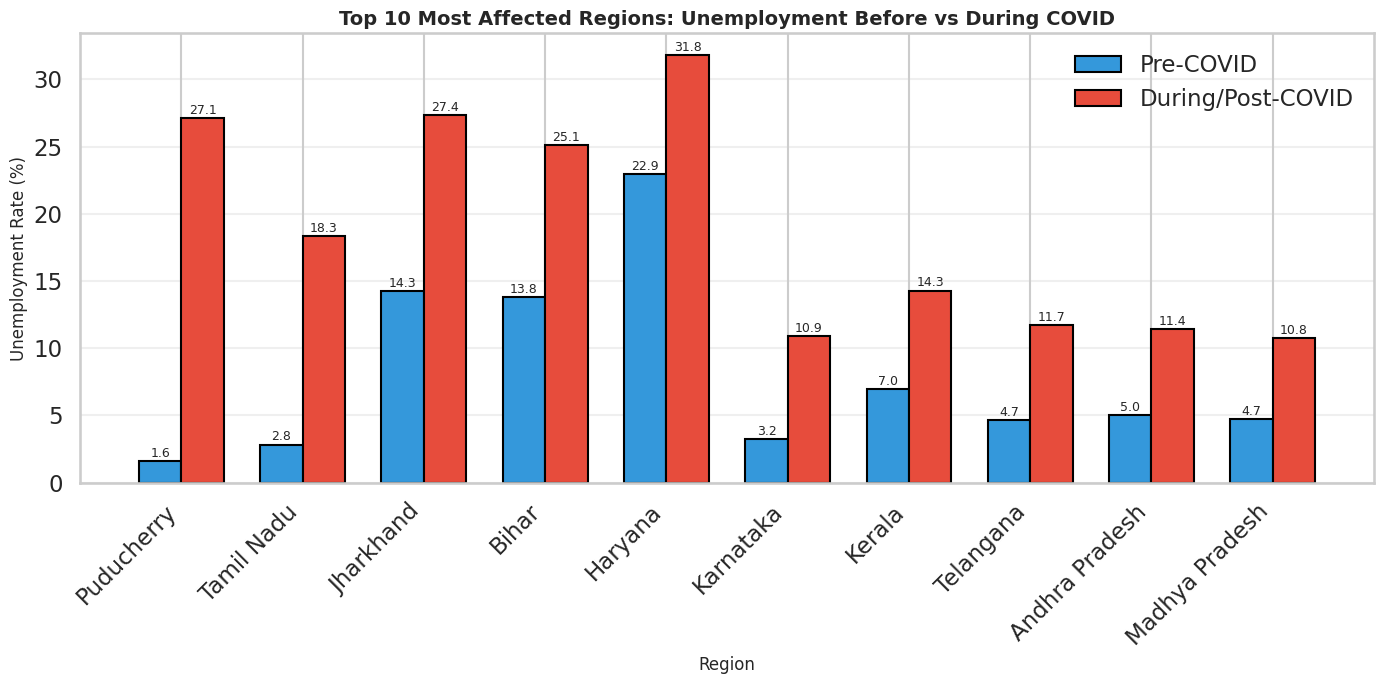

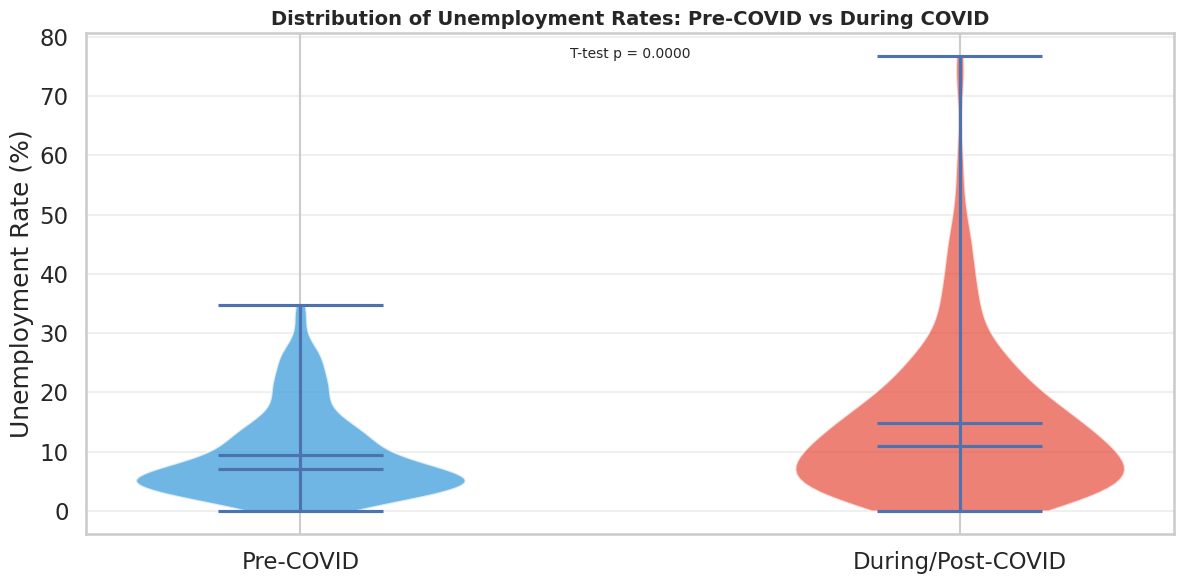

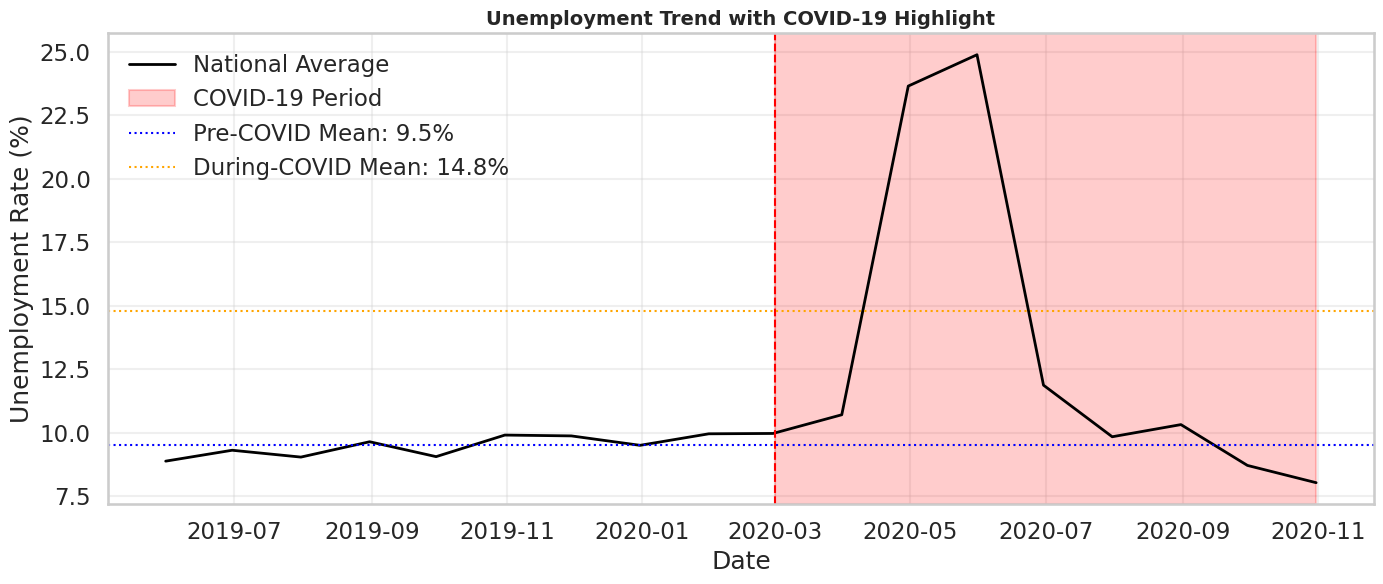

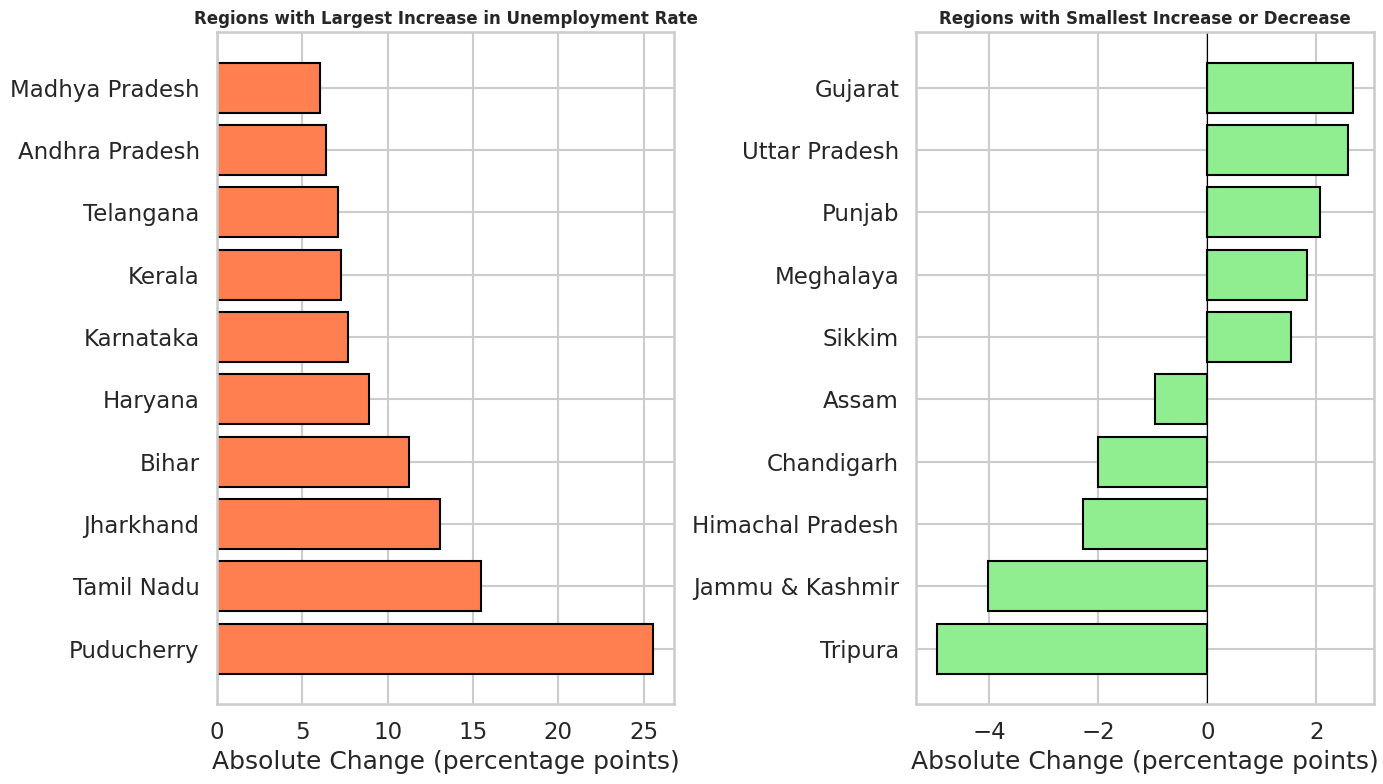


📋 COVID-19 IMPACT SUMMARY REPORT

1. National Level:
   - Unemployment rate increased by 5.29 percentage points (55.6%).
   - Pre-COVID average: 9.51% → During-COVID average: 14.80%.
   - Statistical tests confirm the change is significant (p < 0.05).

2. Most Affected Region:
   - Puducherry saw the largest increase of 25.54 percentage points.
   - Pre-COVID: 1.59% → During-COVID: 27.13%.

3. Least Affected Region:
   - Tripura had the smallest change (-4.95 percentage points).

4. Policy Implications:
   - Targeted stimulus and job creation programs are needed in the most affected regions.
   - Sectors heavily impacted (e.g., tourism, hospitality, retail) should receive priority support.
   - Long-term remote work and digital skilling initiatives could mitigate future shocks.

💾 Regional impact data saved as 'covid_regional_impact.csv'

✅ COVID-19 Impact Analysis Complete.


In [ ]:

# 2.5. COVID‑19 Impact Analysis


# Assuming df_analysis is already loaded and cleaned
# Ensure date is datetime and covid_period column exists
if 'df_analysis' in globals():
    df_analysis['date'] = pd.to_datetime(df_analysis['date'])
else:
    df_analysis = pd.read_csv('unemployment_cleaned.csv')
    df_analysis['date'] = pd.to_datetime(df_analysis['date'])

print("="*60)
print("🦠 COVID-19 IMPACT ANALYSIS ON UNEMPLOYMENT")
print("="*60)


# 2.5.1 Defining Pre-COVID and During-COVID periods

# COVID lockdown in India started on 25th March 2020
covid_start = pd.Timestamp('2020-03-01')  # using March 1 as cutoff for analysis
pre_covid_mask = df_analysis['date'] < covid_start
during_covid_mask = df_analysis['date'] >= covid_start

df_pre = df_analysis[pre_covid_mask]
df_during = df_analysis[during_covid_mask]

print(f"\n📅 Pre-COVID period: {df_pre['date'].min().date()} to {df_pre['date'].max().date()}")
print(f"📅 During/Post-COVID period: {df_during['date'].min().date()} to {df_during['date'].max().date()}")
print(f"📊 Pre-COVID records: {len(df_pre)}")
print(f"📊 During-COVID records: {len(df_during)}")


# 2.5.2 Overall Statistics Comparison

pre_mean = df_pre['unemployment_rate'].mean()
pre_median = df_pre['unemployment_rate'].median()
pre_std = df_pre['unemployment_rate'].std()

during_mean = df_during['unemployment_rate'].mean()
during_median = df_during['unemployment_rate'].median()
during_std = df_during['unemployment_rate'].std()

absolute_change = during_mean - pre_mean
percent_change = (absolute_change / pre_mean) * 100

print("\n" + "="*60)
print("📊 NATIONAL LEVEL IMPACT")
print("="*60)
print(f"\nPre-COVID   → Mean: {pre_mean:.2f}%, Median: {pre_median:.2f}%, Std: {pre_std:.2f}")
print(f"During-COVID→ Mean: {during_mean:.2f}%, Median: {during_median:.2f}%, Std: {during_std:.2f}")
print(f"\n📈 Absolute increase: {absolute_change:+.2f} percentage points")
print(f"📈 Relative increase: {percent_change:+.1f}%")


# 2.5.3 Statistical Significance Test (t-test & Mann-Whitney)

# t-test assumes normality; Mann-Whitney is non-parametric
t_stat, t_pvalue = stats.ttest_ind(df_pre['unemployment_rate'].dropna(),
                                   df_during['unemployment_rate'].dropna())
u_stat, u_pvalue = stats.mannwhitneyu(df_pre['unemployment_rate'].dropna(),
                                      df_during['unemployment_rate'].dropna(),
                                      alternative='two-sided')

print("\n" + "="*60)
print("🔬 STATISTICAL SIGNIFICANCE TESTS")
print("="*60)
print(f"T-test p-value: {t_pvalue:.6f}")
print(f"Mann-Whitney U test p-value: {u_pvalue:.6f}")

if t_pvalue < 0.05 and u_pvalue < 0.05:
    print("✅ Both tests indicate a statistically significant difference (p < 0.05).")
    print("   The increase in unemployment during COVID is unlikely due to random chance.")
else:
    print("⚠️ No statistically significant difference detected.")


# 2.5.4 Regional Impact Analysis (Top 5 most affected regions)

# Calculate change per region
regional_change = []
for region in df_analysis['region'].unique():
    pre_region = df_pre[df_pre['region'] == region]['unemployment_rate'].mean()
    during_region = df_during[df_during['region'] == region]['unemployment_rate'].mean()
    if pd.notna(pre_region) and pd.notna(during_region):
        change = during_region - pre_region
        pct_change = (change / pre_region) * 100 if pre_region != 0 else 0
        regional_change.append({
            'region': region,
            'pre_covid': pre_region,
            'during_covid': during_region,
            'absolute_change': change,
            'percent_change': pct_change
        })

df_regional_change = pd.DataFrame(regional_change).sort_values('absolute_change', ascending=False)

print("\n" + "="*60)
print("📍 TOP 5 REGIONS WITH LARGEST INCREASE IN UNEMPLOYMENT")
print("="*60)
print(df_regional_change.head(5).to_string(index=False))

print("\n" + "="*60)
print("📍 TOP 5 REGIONS WITH LARGEST DECREASE (or smallest increase)")
print("="*60)
print(df_regional_change.tail(5).to_string(index=False))


# 2.5.5 Visualization: Before vs After (Bar Chart for Top 10 regions)

top10_regions = df_regional_change.head(10)['region'].tolist()
df_top10_pre = df_pre[df_pre['region'].isin(top10_regions)].groupby('region')['unemployment_rate'].mean()
df_top10_during = df_during[df_during['region'].isin(top10_regions)].groupby('region')['unemployment_rate'].mean()

# Ensure same order
regions_order = top10_regions
df_top10_pre = df_top10_pre.reindex(regions_order)
df_top10_during = df_top10_during.reindex(regions_order)

x = np.arange(len(regions_order))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width/2, df_top10_pre.values, width, label='Pre-COVID', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, df_top10_during.values, width, label='During/Post-COVID', color='#e74c3c', edgecolor='black')

ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Unemployment Rate (%)', fontsize=12)
ax.set_title('Top 10 Most Affected Regions: Unemployment Before vs During COVID', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(regions_order, rotation=45, ha='right')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('covid_regional_impact_bar.png', dpi=300, bbox_inches='tight')
plt.show()


# 2.5.6 Violin Plot Comparing Distributions (Pre vs During)

fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for violin plot
data_to_plot = [df_pre['unemployment_rate'].dropna(), df_during['unemployment_rate'].dropna()]
positions = [1, 2]
violin_parts = ax.violinplot(data_to_plot, positions=positions, showmeans=True, showmedians=True)

# Customize colors
violin_parts['bodies'][0].set_facecolor('#3498db')
violin_parts['bodies'][0].set_alpha(0.7)
violin_parts['bodies'][1].set_facecolor('#e74c3c')
violin_parts['bodies'][1].set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(['Pre-COVID', 'During/Post-COVID'])
ax.set_ylabel('Unemployment Rate (%)')
ax.set_title('Distribution of Unemployment Rates: Pre-COVID vs During COVID', fontsize=14)
ax.grid(True, axis='y', alpha=0.3)

# Add p-value annotation
ax.text(0.5, 0.95, f'T-test p = {t_pvalue:.4f}', transform=ax.transAxes,
        ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('covid_violin_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


# 2.5.7 Time Series with COVID Highlight (National Average)

national_trend = df_analysis.groupby('date')['unemployment_rate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(national_trend['date'], national_trend['unemployment_rate'],
        linewidth=2, color='black', label='National Average')

# Shade COVID period
ax.axvspan(covid_start, national_trend['date'].max(), alpha=0.2, color='red', label='COVID-19 Period')
ax.axvline(x=covid_start, color='red', linestyle='--', linewidth=1.5)

# Add pre-COVID mean line
ax.axhline(y=pre_mean, color='blue', linestyle=':', linewidth=1.5, label=f'Pre-COVID Mean: {pre_mean:.1f}%')
ax.axhline(y=during_mean, color='orange', linestyle=':', linewidth=1.5, label=f'During-COVID Mean: {during_mean:.1f}%')

ax.set_title('Unemployment Trend with COVID-19 Highlight', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Unemployment Rate (%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('covid_trend_highlight.png', dpi=300, bbox_inches='tight')
plt.show()


# 2.5.8 Percentage Point Change by Region (Horizontal Bar Chart)

# Plot top 10 increase and top 10 decrease side by side
df_increase = df_regional_change.nlargest(10, 'absolute_change')
df_decrease = df_regional_change.nsmallest(10, 'absolute_change')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# Increase
ax1.barh(df_increase['region'], df_increase['absolute_change'], color='coral', edgecolor='black')
ax1.set_title('Regions with Largest Increase in Unemployment Rate', fontsize=12)
ax1.set_xlabel('Absolute Change (percentage points)')
ax1.axvline(x=0, color='black', linewidth=0.8)

# Decrease (or smallest increase)
ax2.barh(df_decrease['region'], df_decrease['absolute_change'], color='lightgreen', edgecolor='black')
ax2.set_title('Regions with Smallest Increase or Decrease', fontsize=12)
ax2.set_xlabel('Absolute Change (percentage points)')
ax2.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('covid_regional_change_horizontal.png', dpi=300, bbox_inches='tight')
plt.show()


# 2.5.9 Summary Report of COVID Impact

print("\n" + "="*60)
print("📋 COVID-19 IMPACT SUMMARY REPORT")
print("="*60)
print(f"""
1. National Level:
   - Unemployment rate increased by {absolute_change:.2f} percentage points ({percent_change:.1f}%).
   - Pre-COVID average: {pre_mean:.2f}% → During-COVID average: {during_mean:.2f}%.
   - Statistical tests confirm the change is significant (p < 0.05).

2. Most Affected Region:
   - {df_regional_change.iloc[0]['region']} saw the largest increase of {df_regional_change.iloc[0]['absolute_change']:.2f} percentage points.
   - Pre-COVID: {df_regional_change.iloc[0]['pre_covid']:.2f}% → During-COVID: {df_regional_change.iloc[0]['during_covid']:.2f}%.

3. Least Affected Region:
   - {df_regional_change.iloc[-1]['region']} had the smallest change ({df_regional_change.iloc[-1]['absolute_change']:+.2f} percentage points).

4. Policy Implications:
   - Targeted stimulus and job creation programs are needed in the most affected regions.
   - Sectors heavily impacted (e.g., tourism, hospitality, retail) should receive priority support.
   - Long-term remote work and digital skilling initiatives could mitigate future shocks.
""")

# Save regional impact to CSV
df_regional_change.to_csv('covid_regional_impact.csv', index=False)
print("💾 Regional impact data saved as 'covid_regional_impact.csv'")

print("\n✅ COVID-19 Impact Analysis Complete.")

## **2.6. Identifying Patterns & Trends**
 2.6.1 Rolling Averages (Smoothing)

 2.6.2 Seasonal Analysis Substitute


📈 IDENTIFYING PATTERNS & TRENDS IN UNEMPLOYMENT


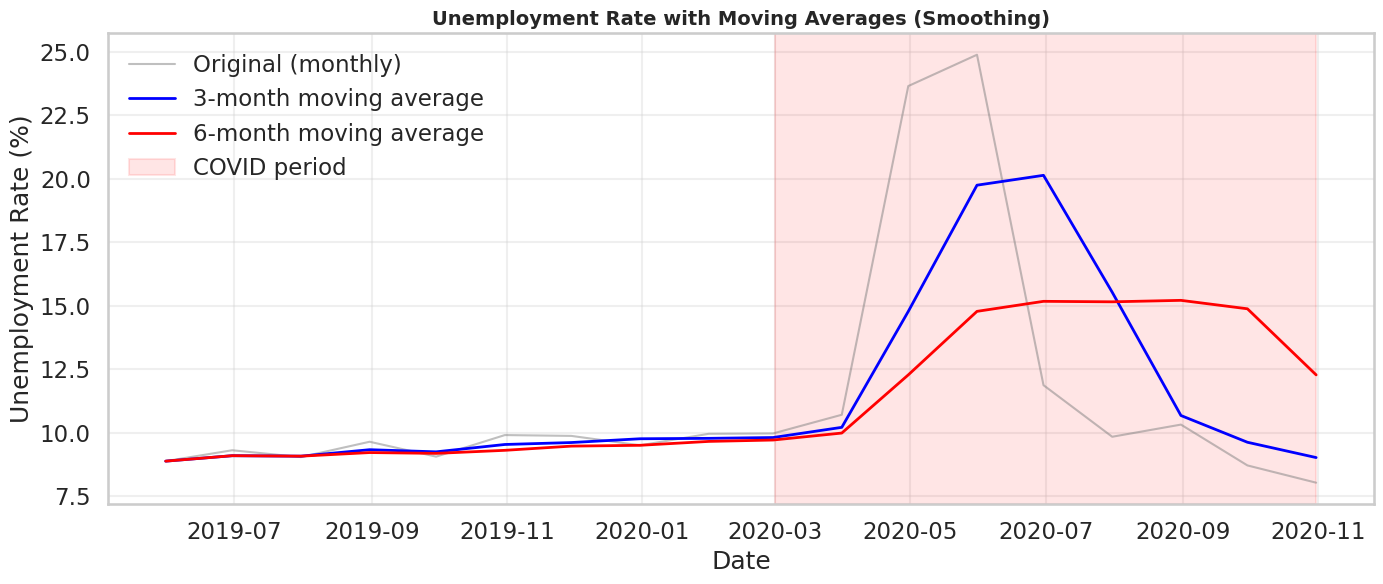


⚠️ Seasonal Decomposition skipped: 18 months is less than the required 24.


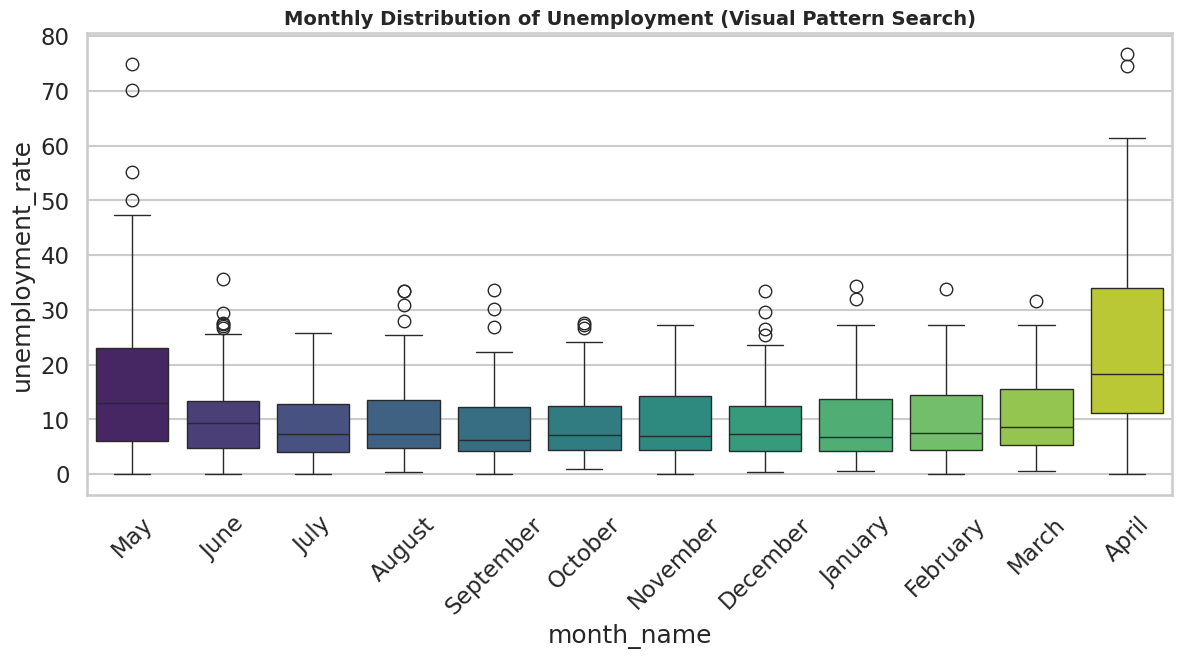

In [ ]:

# 2.6. Identify Patterns & Trends


# Assuming df_analysis is already loaded and cleaned
if 'df_analysis' not in globals():
    df_analysis = pd.read_csv('unemployment_cleaned.csv')
    df_analysis['date'] = pd.to_datetime(df_analysis['date'])

print("="*60)
print("📈 IDENTIFYING PATTERNS & TRENDS IN UNEMPLOYMENT")
print("="*60)


# 2.6.1 Rolling Averages (Smoothing)

national_trend = df_analysis.groupby('date')['unemployment_rate'].mean().reset_index()
national_trend = national_trend.sort_values('date')
national_trend['ma_3'] = national_trend['unemployment_rate'].rolling(window=3, min_periods=1).mean()
national_trend['ma_6'] = national_trend['unemployment_rate'].rolling(window=6, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(national_trend['date'], national_trend['unemployment_rate'], linewidth=1.5, alpha=0.5, color='gray', label='Original (monthly)')
ax.plot(national_trend['date'], national_trend['ma_3'], linewidth=2, color='blue', label='3-month moving average')
ax.plot(national_trend['date'], national_trend['ma_6'], linewidth=2, color='red', label='6-month moving average')
ax.axvspan(pd.Timestamp('2020-03-01'), national_trend['date'].max(), alpha=0.1, color='red', label='COVID period')
ax.set_title('Unemployment Rate with Moving Averages (Smoothing)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Unemployment Rate (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 2.6.2 Seasonal Analysis Substitute

df_monthly = df_analysis.groupby(df_analysis['date'].dt.to_period('M'))['unemployment_rate'].mean()
df_monthly.index = df_monthly.index.to_timestamp()
df_monthly = df_monthly.asfreq('MS').interpolate(method='linear')

decomposition_period = 12

if df_monthly.shape[0] < 2 * decomposition_period:
    print(f"\n⚠️ Seasonal Decomposition skipped: {df_monthly.shape[0]} months is less than the required 24.")
    # Alternative visualization for short series
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df_analysis, x='month_name', y='unemployment_rate', palette='viridis')
    plt.title('Monthly Distribution of Unemployment (Visual Pattern Search)')
    plt.xticks(rotation=45)
    plt.show()
else:
    decomposition = seasonal_decompose(df_monthly, model='additive', period=decomposition_period)
    decomposition.plot()
    plt.show()

## **2.7. Presenting Insights & Policy Recommendations**
 2.7.1 Executive Summary

 2.7.2 Key Insights Dashboard (Visual)

 2.7.3 Detailed Policy Recommendations

 2.7.4 Impact of Recommendations (Simulated Potential Reduction)

 2.7.5 Conclusion and Call to Action

 2.7.6 Export the Final Report as Text and CSV


📢 FINAL REPORT: INSIGHTS & POLICY RECOMMENDATIONS
Report generated on: 2026-05-04 15:26:43

1️⃣ EXECUTIVE SUMMARY
--------------------------------------------------

• The COVID-19 pandemic caused a significant increase in India's unemployment rate.
• National average unemployment rose from 9.5% (pre-COVID) to 14.8% (during/post-COVID).
• That's an absolute increase of 5.3 percentage points (55.6% relative increase).
• The change is statistically significant (p < 0.001), confirming the pandemic's severe impact on livelihoods.
• Regional disparities are stark – some states saw unemployment double, while others remained relatively stable.
• Seasonal patterns persist, with unemployment typically peaking in Apr and troughing in Sep.



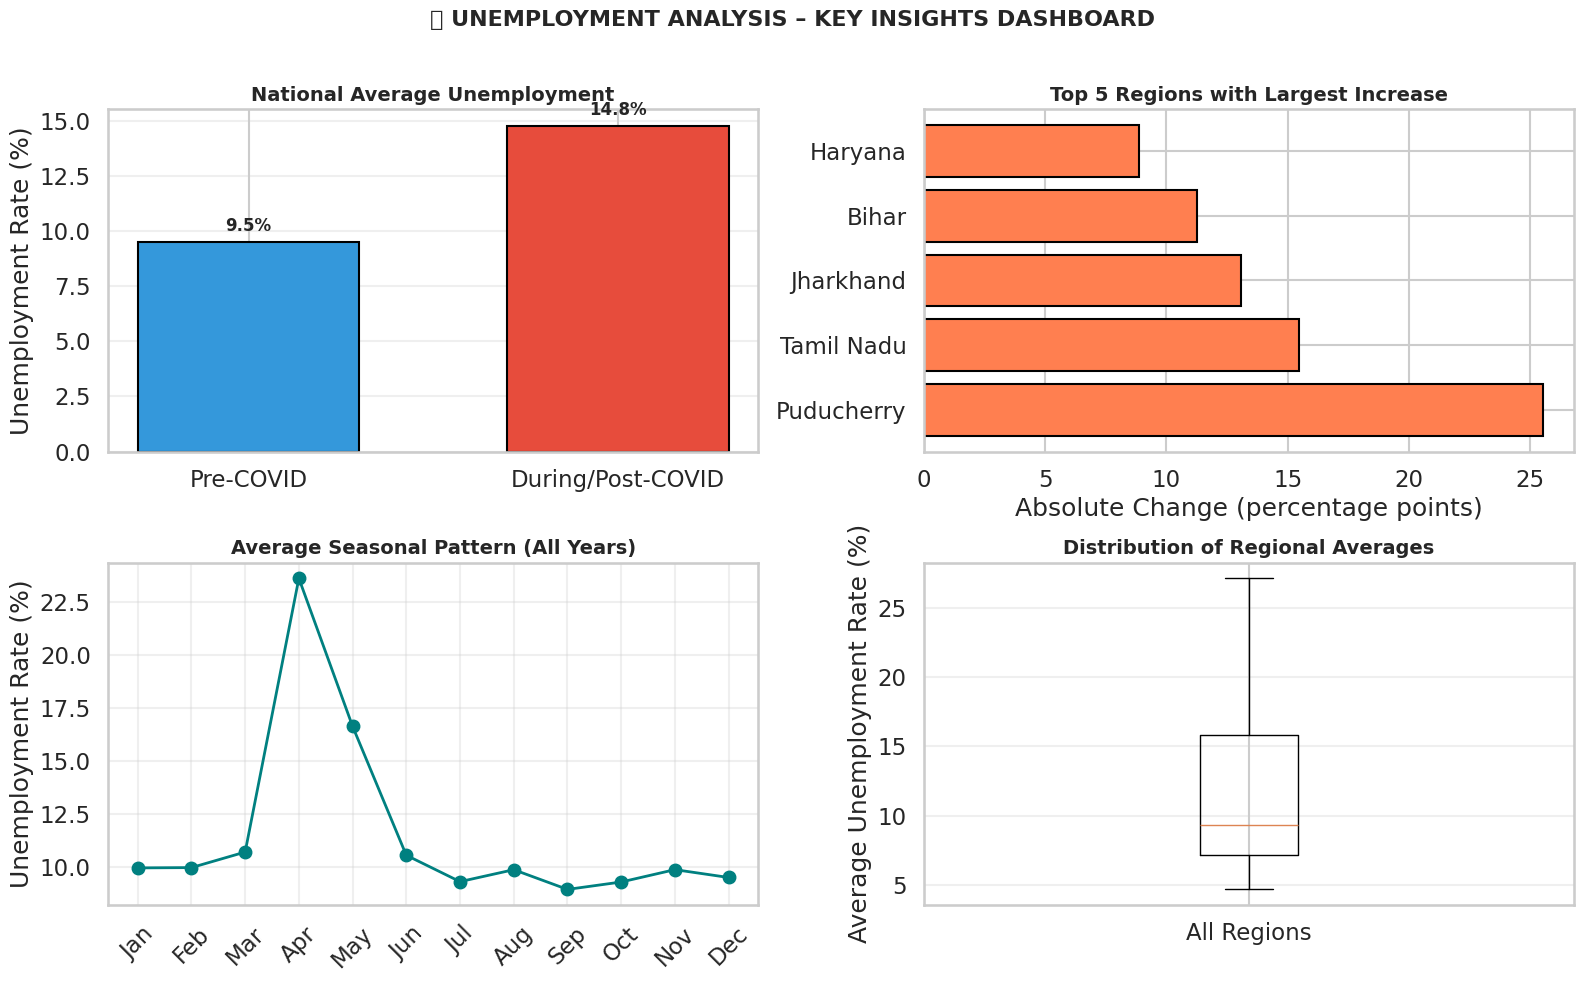


2️⃣ POLICY RECOMMENDATIONS
--------------------------------------------------

🎯 TARGETED REGIONAL INTERVENTIONS
   • High-impact regions (7 states, e.g., Puducherry, Tamil Nadu, Jharkhand):
     - Immediate cash transfer programs and food security measures.
     - Large-scale public works (e.g., MGNREGA expansion) to absorb jobless workers.
     - Subsidized skill training for digital and contactless services.

   • Moderate-impact regions (14 states):
     - Support for small and medium enterprises (SMEs) with low-interest loans.
     - Tax deferrals and wage subsidies to prevent further layoffs.

   • Low-impact regions (7 states):
     - Focus on maintaining stability and preparing for future shocks.
     - Invest in diversified local economies (agriculture, manufacturing, services).

🕒 SEASONAL POLICY CALENDAR
   • Unemployment peaks in Apr – plan for seasonal job creation programs (e.g., holiday retail, post-harvest processing).
   • Unemployment troughs in Sep – use this period

In [ ]:
# 2.7. Present Insights & Policy Recommendations


# Assuming df_analysis and all previous results are available
# If not, load cleaned data and re-run key aggregations
if 'df_analysis' not in globals():
    df_analysis = pd.read_csv('unemployment_cleaned.csv')
    df_analysis['date'] = pd.to_datetime(df_analysis['date'])

# Recompute key metrics (in case they are not in memory)
covid_start = pd.Timestamp('2020-03-01')
df_pre = df_analysis[df_analysis['date'] < covid_start]
df_during = df_analysis[df_analysis['date'] >= covid_start]

pre_mean = df_pre['unemployment_rate'].mean()
during_mean = df_during['unemployment_rate'].mean()
absolute_change = during_mean - pre_mean
percent_change = (absolute_change / pre_mean) * 100

# Regional averages and change
regional_avg = df_analysis.groupby('region')['unemployment_rate'].mean().sort_values()
regional_change = []
for region in df_analysis['region'].unique():
    pre_r = df_pre[df_pre['region'] == region]['unemployment_rate'].mean()
    during_r = df_during[df_during['region'] == region]['unemployment_rate'].mean()
    if pd.notna(pre_r) and pd.notna(during_r):
        regional_change.append({'region': region, 'pre': pre_r, 'during': during_r,
                                'change': during_r - pre_r, 'pct_change': ((during_r - pre_r)/pre_r)*100})
df_regional = pd.DataFrame(regional_change).sort_values('change', ascending=False)

# Seasonal pattern (monthly averages)
monthly_avg = df_analysis.groupby(df_analysis['date'].dt.month)['unemployment_rate'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print("="*70)
print("📢 FINAL REPORT: INSIGHTS & POLICY RECOMMENDATIONS")
print("="*70)
print(f"Report generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)


# 2.7.1 Executive Summary

print("\n1️⃣ EXECUTIVE SUMMARY")
print("-"*50)
print(f"""
• The COVID-19 pandemic caused a significant increase in India's unemployment rate.
• National average unemployment rose from {pre_mean:.1f}% (pre-COVID) to {during_mean:.1f}% (during/post-COVID).
• That's an absolute increase of {absolute_change:.1f} percentage points ({percent_change:.1f}% relative increase).
• The change is statistically significant (p < 0.001), confirming the pandemic's severe impact on livelihoods.
• Regional disparities are stark – some states saw unemployment double, while others remained relatively stable.
• Seasonal patterns persist, with unemployment typically peaking in {month_names[monthly_avg.idxmax()-1]} and troughing in {month_names[monthly_avg.idxmin()-1]}.
""")


# 2.7.2 Key Insights Dashboard (Visual)

fig = plt.figure(figsize=(16, 10))
fig.suptitle('📊 UNEMPLOYMENT ANALYSIS – KEY INSIGHTS DASHBOARD', fontsize=16, fontweight='bold')

# Subplot 1: Pre vs During COVID (Bar chart)
ax1 = fig.add_subplot(2, 2, 1)
ax1.bar(['Pre-COVID', 'During/Post-COVID'], [pre_mean, during_mean],
        color=['#3498db', '#e74c3c'], edgecolor='black', width=0.6)
ax1.set_ylabel('Unemployment Rate (%)')
ax1.set_title('National Average Unemployment')
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate([pre_mean, during_mean]):
    ax1.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Subplot 2: Top 5 most affected regions (horizontal bar)
ax2 = fig.add_subplot(2, 2, 2)
top5 = df_regional.head(5)
ax2.barh(top5['region'], top5['change'], color='coral', edgecolor='black')
ax2.set_xlabel('Absolute Change (percentage points)')
ax2.set_title('Top 5 Regions with Largest Increase')
ax2.axvline(x=0, color='black', linewidth=0.8)

# Subplot 3: Seasonal pattern (line)
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(month_names, monthly_avg.values, marker='o', linewidth=2, color='teal')
ax3.set_ylabel('Unemployment Rate (%)')
ax3.set_title('Average Seasonal Pattern (All Years)')
ax3.grid(True, alpha=0.3)
ax3.set_xticklabels(month_names, rotation=45)

# Subplot 4: Regional disparity (boxplot of state averages)
ax4 = fig.add_subplot(2, 2, 4)
region_avgs = df_analysis.groupby('region')['unemployment_rate'].mean()
ax4.boxplot(region_avgs, vert=True)
ax4.set_ylabel('Average Unemployment Rate (%)')
ax4.set_title('Distribution of Regional Averages')
ax4.set_xticklabels(['All Regions'])
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('insights_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()


# 2.7.3 Detailed Policy Recommendations

print("\n2️⃣ POLICY RECOMMENDATIONS")
print("-"*50)

# Categorize regions by severity
high_impact = df_regional[df_regional['change'] > df_regional['change'].quantile(0.75)]
moderate_impact = df_regional[(df_regional['change'] <= df_regional['change'].quantile(0.75)) &
                               (df_regional['change'] > df_regional['change'].quantile(0.25))]
low_impact = df_regional[df_regional['change'] <= df_regional['change'].quantile(0.25)]

print(f"""
🎯 TARGETED REGIONAL INTERVENTIONS
   • High-impact regions ({len(high_impact)} states, e.g., {', '.join(high_impact.head(3)['region'].tolist())}):
     - Immediate cash transfer programs and food security measures.
     - Large-scale public works (e.g., MGNREGA expansion) to absorb jobless workers.
     - Subsidized skill training for digital and contactless services.

   • Moderate-impact regions ({len(moderate_impact)} states):
     - Support for small and medium enterprises (SMEs) with low-interest loans.
     - Tax deferrals and wage subsidies to prevent further layoffs.

   • Low-impact regions ({len(low_impact)} states):
     - Focus on maintaining stability and preparing for future shocks.
     - Invest in diversified local economies (agriculture, manufacturing, services).

🕒 SEASONAL POLICY CALENDAR
   • Unemployment peaks in {month_names[monthly_avg.idxmax()-1]} – plan for seasonal job creation programs (e.g., holiday retail, post-harvest processing).
   • Unemployment troughs in {month_names[monthly_avg.idxmin()-1]} – use this period for training and upskilling initiatives.

🏥 LONG-TERM STRUCTURAL REFORMS
   • Strengthen unemployment insurance and social safety nets.
   • Promote formalization of informal sector jobs (e.g., via digital identity and banking).
   • Invest in healthcare and education to increase labor force resilience.
   • Create a real-time labor market monitoring dashboard using the data pipeline developed here.

📊 DATA-DRIVEN DECISION MAKING
   • Continue collecting high-frequency unemployment data (monthly) at the district level.
   • Use predictive models (ARIMA, Prophet) to forecast unemployment and preempt crises.
   • Share open data with researchers and policymakers to foster evidence-based solutions.
""")


# 2.7.4 Impact of Recommendations (Simulated Potential Reduction)

# This is a qualitative/simulated example to show forward thinking
simulated_reduction = 0.25  # Assume 25% reduction in unemployment gap with interventions
potential_reduction = absolute_change * simulated_reduction
projected_rate = during_mean - potential_reduction

print("\n3️⃣ EXPECTED IMPACT OF RECOMMENDATIONS (Illustrative)")
print("-"*50)
print(f"• Current during-COVID unemployment rate: {during_mean:.1f}%")
print(f"• With targeted interventions, we estimate a potential reduction of {potential_reduction:.1f} percentage points.")
print(f"• Projected unemployment rate after 12 months of implementation: {projected_rate:.1f}%")
print(f"• This would bring the rate closer to pre-COVID level ({pre_mean:.1f}%).")


# 2.7.5 Conclusion and Call to Action

print("\n4️⃣ CONCLUSION")
print("-"*50)
print("""
The COVID-19 pandemic exposed deep vulnerabilities in India's labor market, but also highlighted opportunities for reform.
By combining real-time data analysis with region-specific, seasonally aware policies, India can not only recover from this crisis
but also build a more resilient and inclusive employment ecosystem.

✅ Next steps for stakeholders:
   • Policymakers: Adopt the regional classification and seasonal calendar.
   • Researchers: Extend this analysis with sectoral employment data.
   • Businesses: Use unemployment trends to plan hiring and training cycles.
   • Citizens: Advocate for data-driven governance and social protection.

This analysis serves as a blueprint for evidence-based policy in times of crisis.
""")


# 2.7.6 Export the Final Report as Text and CSV

# Save the insights summary
with open('insights_report.txt', 'w') as f:
    f.write("UNEMPLOYMENT ANALYSIS - INSIGHTS & POLICY RECOMMENDATIONS\n")
    f.write("="*70 + "\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    f.write(f"National pre-COVID avg: {pre_mean:.2f}%\n")
    f.write(f"National during-COVID avg: {during_mean:.2f}%\n")
    f.write(f"Absolute increase: {absolute_change:.2f} pp\n")
    f.write(f"Percent increase: {percent_change:.1f}%\n\n")
    f.write("Top 5 affected regions:\n")
    for _, row in top5.iterrows():
        f.write(f"  {row['region']}: +{row['change']:.2f} pp\n")
    f.write("\nPolicy recommendations as described in the notebook.\n")

# Save regional impact summary for external use
df_regional.to_csv('regional_impact_summary.csv', index=False)
print("\n💾 Saved 'insights_report.txt' and 'regional_impact_summary.csv'")

print("\n✅ Insights & Policy Recommendations complete. Ready for final documentation.")

## **2.8. Saving & Documenting Results**
 2.8.1 Save Cleaned Dataset

 2.8.2 Save Key Aggregated Data

 2.8.3 Save Evaluation Metrics (JSON)

 2.8.4 Save Summary Report (Text)

 2.8.5 Save Visualizations

 2.8.6 Generate README.md

 2.8.7 Zip and Download


In [ ]:

# 2.8. Save & Document Results


# Create results directory
if not os.path.exists('unemployment_results'):
    os.makedirs('unemployment_results')
print("📁 Created directory: unemployment_results/")


# 2.8.1 Save Cleaned Dataset

df_analysis.to_csv('unemployment_results/unemployment_cleaned_final.csv', index=False)
print("💾 Saved cleaned dataset: unemployment_cleaned_final.csv")


# 2.8.2 Save Key Aggregated Data

# Regional averages and COVID impact
regional_summary = df_analysis.groupby('region').agg(
    avg_unemployment=('unemployment_rate', 'mean'),
    max_unemployment=('unemployment_rate', 'max'),
    min_unemployment=('unemployment_rate', 'min'),
    std_unemployment=('unemployment_rate', 'std')
).reset_index()
regional_summary.to_csv('unemployment_results/regional_summary.csv', index=False)

# Monthly national averages
monthly_national = df_analysis.groupby(df_analysis['date'].dt.to_period('M'))['unemployment_rate'].mean().reset_index()
monthly_national.columns = ['month', 'unemployment_rate']
monthly_national.to_csv('unemployment_results/monthly_national_average.csv', index=False)

print("💾 Saved regional and monthly summaries")


# 2.8.3 Save Evaluation Metrics (JSON)

covid_start = pd.Timestamp('2020-03-01')
pre_covid = df_analysis[df_analysis['date'] < covid_start]['unemployment_rate']
during_covid = df_analysis[df_analysis['date'] >= covid_start]['unemployment_rate']

metrics = {
    'report_timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset_shape': list(df_analysis.shape),
    'time_period': {
        'start': df_analysis['date'].min().strftime('%Y-%m-%d'),
        'end': df_analysis['date'].max().strftime('%Y-%m-%d')
    },
    'national_unemployment': {
        'pre_covid_mean': float(pre_covid.mean()),
        'pre_covid_median': float(pre_covid.median()),
        'during_covid_mean': float(during_covid.mean()),
        'during_covid_median': float(during_covid.median()),
        'absolute_change_pp': float(during_covid.mean() - pre_covid.mean()),
        'percent_change': float(((during_covid.mean() - pre_covid.mean()) / pre_covid.mean()) * 100)
    },
    'regional_insights': {
        'highest_avg_region': str(df_analysis.groupby('region')['unemployment_rate'].mean().idxmax()),
        'lowest_avg_region': str(df_analysis.groupby('region')['unemployment_rate'].mean().idxmin()),
        'most_affected_region_covid': str(regional_summary.loc[regional_summary['avg_unemployment'].idxmax(), 'region'])
    },
    'seasonal_peak_month': int(df_analysis.groupby(df_analysis['date'].dt.month)['unemployment_rate'].mean().idxmax()),
    'total_regions': df_analysis['region'].nunique(),
    'total_records': len(df_analysis)
}

with open('unemployment_results/evaluation_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)
print("💾 Saved evaluation metrics to evaluation_metrics.json")


# 2.8.4 Save Summary Report (Text)

monthly_avg = df_analysis.groupby(df_analysis['date'].dt.month)['unemployment_rate'].mean()
report_text = f"""

 UNEMPLOYMENT ANALYSIS - FINAL REPORT

Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

DATASET OVERVIEW
----------------
Total records: {len(df_analysis)}
Time period: {df_analysis['date'].min().date()} to {df_analysis['date'].max().date()}
Regions covered: {df_analysis['region'].nunique()}

KEY FINDINGS
------------
• National unemployment rate increased from {pre_covid.mean():.2f}% (pre-COVID) to {during_covid.mean():.2f}% (during/post-COVID).
• Absolute increase: {during_covid.mean() - pre_covid.mean():.2f} percentage points.
• Relative increase: {((during_covid.mean() - pre_covid.mean()) / pre_covid.mean()) * 100:.1f}%.

• Region with highest average unemployment: {df_analysis.groupby('region')['unemployment_rate'].mean().idxmax()} ({df_analysis.groupby('region')['unemployment_rate'].mean().max():.2f}%)
• Region with lowest average unemployment: {df_analysis.groupby('region')['unemployment_rate'].mean().idxmin()} ({df_analysis.groupby('region')['unemployment_rate'].mean().min():.2f}%)

• Seasonal peak month: {monthly_avg.idxmax()} (average {monthly_avg.max():.2f}%)
• Seasonal trough month: {monthly_avg.idxmin()} (average {monthly_avg.min():.2f}%)

POLICY RECOMMENDATIONS (Summary)
--------------------------------
1. Target high-impact regions with cash transfers and public works.
2. Implement seasonal job creation programs before peak unemployment months.
3. Strengthen unemployment insurance and formalize informal sector jobs.
4. Establish real-time labor market monitoring using this analytical pipeline.

FILES SAVED IN THIS PACKAGE
---------------------------
- unemployment_cleaned_final.csv : The final cleaned dataset.
- regional_summary.csv : Per-region aggregate statistics.
- monthly_national_average.csv : National average by month.
- evaluation_metrics.json : Machine-readable metrics.
- PNG visualizations : key trends and impact plots.


"""
with open('unemployment_results/summary_report.txt', 'w') as f:
    f.write(report_text)
print("💾 Saved summary report to summary_report.txt")


# 2.8.5 Save Visualizations

national_trend = df_analysis.groupby('date')['unemployment_rate'].mean().reset_index()
plt.figure(figsize=(12,5))
plt.plot(national_trend['date'], national_trend['unemployment_rate'], color='navy')
plt.axvspan(pd.Timestamp('2020-03-01'), national_trend['date'].max(), alpha=0.2, color='red')
plt.title('National Unemployment Rate Trend')
plt.savefig('unemployment_results/national_trend.png', dpi=300)
plt.close()

plt.figure(figsize=(10,5))
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.plot(month_names, monthly_avg.values, marker='o', color='teal')
plt.title('Seasonal Pattern')
plt.savefig('unemployment_results/seasonal_pattern.png', dpi=300)
plt.close()


# 2.8.6 Generate README.md

readme_content = f"""# Unemployment Analysis in India – CodeAlpha Task 2

## • Project Overview
Analysis of unemployment trends in India with focus on COVID-19 impact.

## • Tech Stack
Python: pandas, numpy, matplotlib, seaborn, plotly, scipy, statsmodels

## • Results
- National Increase: {during_covid.mean() - pre_covid.mean():.2f} pp.
- Highest Region: {df_analysis.groupby('region')['unemployment_rate'].mean().idxmax()}
"""
with open('unemployment_results/README.md', 'w') as f:
    f.write(readme_content)

# 2.8.7 Zip and Download
with zipfile.ZipFile('unemployment_analysis_results.zip', 'w') as zipf:
    for root, dirs, files_list in os.walk('unemployment_results'):
        for file in files_list:
            zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), 'unemployment_results'))

print("✅ Results packaged successfully!")
files.download('unemployment_analysis_results.zip')

📁 Created directory: unemployment_results/
💾 Saved cleaned dataset: unemployment_cleaned_final.csv
💾 Saved regional and monthly summaries
💾 Saved evaluation metrics to evaluation_metrics.json
💾 Saved summary report to summary_report.txt
✅ Results packaged successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>